
# Event‑Based Queueing Simulation: Exp(Arrivals), Uniform(Service)

This notebook simulates a **single‑server FIFO queue** with
- **Exponential interarrival times** with rate $\lambda$
- **Uniform service times** on $[a,b]$
- Infinite buffer, first‑come first‑served

The engine is **event‑driven**: at each step we advance to the earlier of the next **arrival** or the next **departure**, update the system state, collect statistics, and then schedule the subsequent event(s).

We'll keep the design modular so you can add extensions later (e.g., multiple servers, balking/reneging, priorities, etc.).


In [1]:

import math
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict

# Reproducibility
rng = np.random.default_rng(12345)

@dataclass
class Config:
    # Interarrival: Exp(rate=lambda_)
    lambda_: float = 0.8              # arrivals per unit time
    # Service: Uniform[a, b]
    service_a: float = 0.8
    service_b: float = 1.2
    # Termination controls (choose one):
    t_end: float | None = 2000.0      # simulate until time >= t_end (if not None)
    n_complete: int | None = None     # or simulate until this many completions
    # Data capture throttling
    record_state_trajectory: bool = True   # track queue length over time

cfg = Config()
asdict(cfg)


{'lambda_': 0.8,
 'service_a': 0.8,
 'service_b': 1.2,
 't_end': 2000.0,
 'n_complete': None,
 'record_state_trajectory': True}

In [3]:

class SingleServerQueue:
    """
    Event-based simulation of a GI/G/1 (here Exp/Uniform/1) FIFO queue with infinite buffer.
    Arrivals: exponential interarrival with rate lambda_
    Service: uniform on [service_a, service_b]
    """
    ARRIVAL = 0
    DEPART  = 1

    def __init__(self, cfg: Config, rng: np.random.Generator | None = None):
        self.cfg = cfg
        self.rng = np.random.default_rng() if rng is None else rng
        # State
        self.t = 0.0                      # current time
        self.n_in_system = 0              # number in system (queue + service)
        self.server_busy = False
        # Event times (None means unscheduled)
        self.t_next_arrival = self.t + self._sample_interarrival()
        self.t_next_depart  = None        # no departure until first service starts
        # Statistics
        self.arrival_times = []           # per-customer arrival times
        self.start_service_times = []     # per-customer service start times
        self.departure_times = []         # per-customer departure times
        self.wait_times = []              # per-customer waiting times (start_service - arrival)
        self.system_times = []            # per-customer total time in system (departure - arrival)
        self.service_times_drawn = []     # per-customer realized service durations
        # For time averages via area-under-curve
        self._areas_n = 0.0               # integral of n_in_system dt
        self._last_t = self.t
        # Trajectory
        self.state_t = [self.t] if self.cfg.record_state_trajectory else []
        self.state_n = [self.n_in_system] if self.cfg.record_state_trajectory else []

        # Queue of waiting customers (arrival timestamps). FIFO
        self.queue = []

    # --- Sampling helpers ---
    def _sample_interarrival(self) -> float:
        return self.rng.exponential(1.0 / self.cfg.lambda_)

    def _sample_service(self) -> float:
        a, b = self.cfg.service_a, self.cfg.service_b
        return self.rng.uniform(a, b)

    # --- Internal utilities ---
    def _update_area(self, new_t: float):
        dt = new_t - self._last_t
        if dt > 0:
            self._areas_n += self.n_in_system * dt
            self._last_t = new_t

    def _record_state(self):
        if self.cfg.record_state_trajectory:
            self.state_t.append(self.t)
            self.state_n.append(self.n_in_system)

    # --- Event handlers ---
    def _handle_arrival(self):
        self.n_in_system += 1
        self.arrival_times.append(self.t)
        self.queue.append(self.t)

        if not self.server_busy:  # immediately start service
            self.server_busy = True
            arrival_t = self.queue.pop(0)
            service = self._sample_service()
            self.service_times_drawn.append(service)
            start_t = self.t
            self.start_service_times.append(start_t)
            self.wait_times.append(start_t - arrival_t)
            self.t_next_depart = self.t + service

        # schedule next arrival
        self.t_next_arrival = self.t + self._sample_interarrival()

    def _handle_departure(self):
        self.n_in_system -= 1
        depart_t = self.t
        self.departure_times.append(depart_t)

        # Match up service for stats (safe check)
        # arrival index i corresponds to departure index i in FCFS
        i = len(self.departure_times) - 1
        arrival_t = self.arrival_times[i]
        self.system_times.append(depart_t - arrival_t)

        if self.queue:  # start next service
            arrival_t2 = self.queue.pop(0)
            service = self._sample_service()
            self.service_times_drawn.append(service)
            start_t = self.t
            self.start_service_times.append(start_t)
            self.wait_times.append(start_t - arrival_t2)
            self.t_next_depart = self.t + service
            self.server_busy = True
        else:
            self.t_next_depart = None
            self.server_busy = False

    # --- Main simulation loop ---
    def run(self):
        # Stopping conditions
        target_t = self.cfg.t_end if self.cfg.t_end is not None else math.inf
        target_n = self.cfg.n_complete if self.cfg.n_complete is not None else math.inf

        while (self.t < target_t) and (len(self.departure_times) < target_n):
            # Choose next event
            next_arrival = self.t_next_arrival
            next_depart  = self.t_next_depart if self.t_next_depart is not None else math.inf

            if next_arrival <= next_depart:
                # advance to arrival
                self._update_area(next_arrival)
                self.t = next_arrival
                self._handle_arrival()
            else:
                # advance to departure
                self._update_area(next_depart)
                self.t = next_depart
                self._handle_departure()

            self._record_state()

        # Final area update to time horizon if stopping by t_end
        final_t = min(self.t, target_t)
        self._update_area(final_t)

    # --- Summaries ---
    def summary(self) -> dict:
        sim_time = self.t if self.cfg.t_end is None else min(self.t, self.cfg.t_end)
        arrivals = len(self.arrival_times)
        departures = len(self.departure_times)

        avg_L = self._areas_n / sim_time if sim_time > 0 else np.nan
        lam_hat = arrivals / sim_time if sim_time > 0 else np.nan
        rho_hat = np.sum(self.service_times_drawn) / sim_time if sim_time > 0 else np.nan
        Wq = float(np.mean(self.wait_times)) if self.wait_times else np.nan
        W  = float(np.mean(self.system_times)) if self.system_times else np.nan
        Lq = lam_hat * Wq if not np.isnan(lam_hat) and not np.isnan(Wq) else np.nan
        L_from_Little = lam_hat * W if not np.isnan(lam_hat) and not np.isnan(W) else np.nan

        return {
            "sim_time": sim_time,
            "arrivals": arrivals,
            "departures": departures,
            "lambda_hat": lam_hat,
            "avg_number_in_system_L": avg_L,
            "utilization_rho_hat": rho_hat,
            "avg_wait_in_queue_Wq": Wq,
            "avg_time_in_system_W": W,
            "L_via_Little_lambdaW": L_from_Little,
            "mean_service_time_drawn": float(np.mean(self.service_times_drawn)) if self.service_times_drawn else np.nan,
        }


In [4]:

# Run base simulation
sim = SingleServerQueue(cfg, rng)
sim.run()
summary = sim.summary()
summary


{'sim_time': 2000.0,
 'arrivals': 1617,
 'departures': 1616,
 'lambda_hat': 0.8085,
 'avg_number_in_system_L': 2.816098866863088,
 'utilization_rho_hat': np.float64(0.8074609653864784),
 'avg_wait_in_queue_Wq': 2.4849177440934365,
 'avg_time_in_system_W': 3.4852708748305634,
 'L_via_Little_lambdaW': 2.8178415023005106,
 'mean_service_time_drawn': 0.9987148613314513}

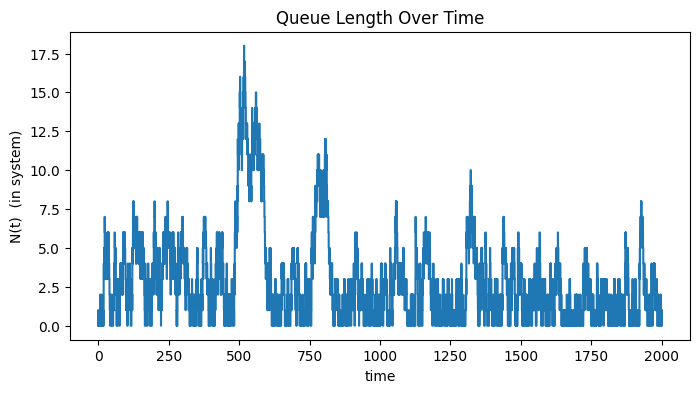

In [5]:

# Number-in-system trajectory
if cfg.record_state_trajectory:
    plt.figure(figsize=(8,4))
    plt.step(sim.state_t, sim.state_n, where="post")
    plt.xlabel("time")
    plt.ylabel("N(t)  (in system)")
    plt.title("Queue Length Over Time")
    plt.show()


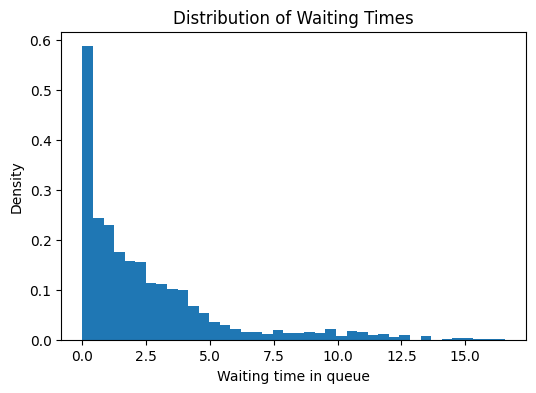

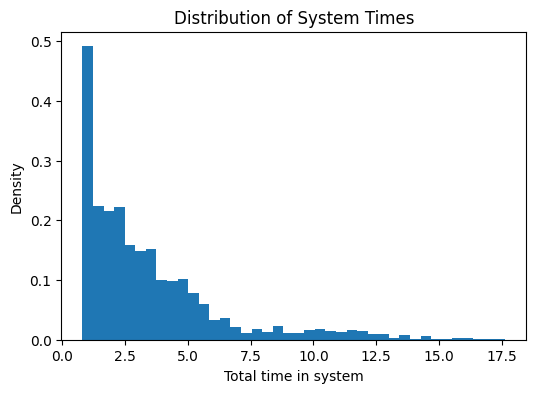

In [6]:

# Histograms of delays
if sim.wait_times:
    plt.figure(figsize=(6,4))
    plt.hist(sim.wait_times, bins=40, density=True)
    plt.xlabel("Waiting time in queue")
    plt.ylabel("Density")
    plt.title("Distribution of Waiting Times")
    plt.show()

if sim.system_times:
    plt.figure(figsize=(6,4))
    plt.hist(sim.system_times, bins=40, density=True)
    plt.xlabel("Total time in system")
    plt.ylabel("Density")
    plt.title("Distribution of System Times")
    plt.show()


In [7]:

def run_many(lambda_list, a, b, t_end=2000, seed=12345):
    results = []
    for lam in lambda_list:
        rng = np.random.default_rng(seed)
        cfg = Config(lambda_=lam, service_a=a, service_b=b, t_end=t_end, n_complete=None)
        sim = SingleServerQueue(cfg, rng)
        sim.run()
        out = sim.summary()
        out["lambda_param"] = lam
        results.append(out)
    return results

# Example sweep (commented by default)
# lambdas = np.linspace(0.4, 1.2, 7)
# res = run_many(lambdas, a=0.8, b=1.2, t_end=2000)
# res



## Extensions (placeholders)

- **Multiple servers (c servers)**: maintain a min-heap of next-departure times, track idle/busy servers.
- **Balking / Reneging**: add thresholds and patience times.
- **Priority classes**: separate queues with preemptive/nonpreemptive discipline.
- **Blocking / Finite buffer**: drop or block arrivals when buffer is full.
- **Time-varying arrival rates**: replace Exp with nonhomogeneous Poisson thinning.
- **Warm‑up removal**: discard initial transient for steady‑state estimates.



---
*Notebook generated automatically. Edit freely; the simulation code is self‑contained.*
